In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

## Data Loading

In [41]:
df = pd.read_csv('default of credit card clients.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [43]:
# To check the number of rows and columns in the dataset
df.shape

(30000, 25)

In [44]:
# Check the structure of the data
df.describe(include="all")

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


## EDA

In [45]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
# Rename columns for clarity & consistency
df.rename(columns={
    'LIMIT_BAL': 'Credit_Limit',
    'SEX': 'Gender', 
    'EDUCATION': 'Education_Level',
    'MARRIAGE': 'Marital_Status',
    'AGE': 'Age',
    'PAY_0': 'Repayment_Status_Sept',
    'PAY_2': 'Repayment_Status_Aug',
    'PAY_3': 'Repayment_Status_July',
    'PAY_4': 'Repayment_Status_June',
    'PAY_5': 'Repayment_Status_May',
    'PAY_6': 'Repayment_Status_April',
    'BILL_AMT1': 'Bill_Amount_Sept',
    'BILL_AMT2': 'Bill_Amount_Aug',
    'BILL_AMT3': 'Bill_Amount_July',
    'BILL_AMT4': 'Bill_Amount_June',
    'BILL_AMT5': 'Bill_Amount_May',
    'BILL_AMT6': 'Bill_Amount_April',
    'PAY_AMT1': 'Payment_Amount_Sept',
    'PAY_AMT2': 'Payment_Amount_Aug',
    'PAY_AMT3': 'Payment_Amount_July',
    'PAY_AMT4': 'Payment_Amount_June',
    'PAY_AMT5': 'Payment_Amount_May',
    'PAY_AMT6': 'Payment_Amount_April',
    'default.payment.next.month': 'Default'
}, inplace=True)

In [48]:
# Fixing undocumented data
# Based on UCI documentation:
# EDUCATION: 0, 5, 6 are undocumented. We group them into 4 (Others).
for i in range(len(df)):
    if df.loc[i, 'Education_Level'] in [0, 5, 6]:
        df.loc[i, 'Education_Level'] = 4

# MARRIAGE: 0 is undocumented. We group it into 3 (Others).
for i in range(len(df)):
    if df.loc[i, 'Marital_Status'] == 0:
        df.loc[i, 'Marital_Status'] = 3

# Fixing negative numerical values in repayment columns
# -2 (No consumption), -1 (Paid in full), 0 (Revolving credit) are all good customers
# To make the scale monotonic (0 = Good, 1 = 1 month delay, etc.), we map negatives to 0.

pay_cols = [
    'Repayment_Status_Sept',
    'Repayment_Status_Aug',
    'Repayment_Status_July',
    'Repayment_Status_June',
    'Repayment_Status_May',
    'Repayment_Status_April'
]

for col in pay_cols:
    for i in range(len(df)):
        if df.loc[i, col] <= 0:
            df.loc[i, col] = 0

print('Cleaned the Data')
df.head()

Cleaned the Data


,ID,Credit_Limit,Gender,Education_Level,Marital_Status,Age,Repayment_Status_Sept,Repayment_Status_Aug,Repayment_Status_July,Repayment_Status_June,...,Bill_Amount_June,Bill_Amount_May,Bill_Amount_April,Payment_Amount_Sept,Payment_Amount_Aug,Payment_Amount_July,Payment_Amount_June,Payment_Amount_May,Payment_Amount_April,Default
0,1,20000.0,2,2,1,24,2,2,0,0,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,0,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,0,0,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


#### As we can see in the above dataset that the data is unlabelled so we need to label the dataset in order to understand the data in a better manner

In [49]:
df_labelled = df.copy()
df_labelled['Gender'] = df['Gender'].map({1: 'Male', 2: 'Female'})
df_labelled['Marital_Status'] = df['Marital_Status'].map({1: 'Married', 2: 'Single', 3: 'Other'})
df_labelled['Education_Level'] = df['Education_Level'].map({
    1: 'Graduate School',
    2: 'University',
    3: 'High School',
    4: 'Other',
    5: 'Unknown',
    6: 'Unknown',
    0: 'Unknown'
})

# Define the mapping for repayment status
repayment_status_map = {
    0: 'Revolving credit',
    1: 'Delay 1 month',
    2: 'Delay 2 months',
    3: 'Delay 3 months',
    4: 'Delay 4 months',
    5: 'Delay 5 months',
    6: 'Delay 6 months',
    7: 'Delay 7 months',
    8: 'Delay 8 months',
    9: 'Delay 9+ months'
}

# List of repayment status columns
repayment_cols = [
    'Repayment_Status_Sept',
    'Repayment_Status_Aug',
    'Repayment_Status_July',
    'Repayment_Status_June',
    'Repayment_Status_May',
    'Repayment_Status_April'
]

# Apply the mapping to each repayment status column
for col in repayment_cols:
    df_labelled[col] = df[col].map(repayment_status_map)

print(f"Data values are labelled successfully")
# Display the cleaned DataFrame
df_labelled.head()

Data values are labelled successfully


,ID,Credit_Limit,Gender,Education_Level,Marital_Status,Age,Repayment_Status_Sept,Repayment_Status_Aug,Repayment_Status_July,Repayment_Status_June,...,Bill_Amount_June,Bill_Amount_May,Bill_Amount_April,Payment_Amount_Sept,Payment_Amount_Aug,Payment_Amount_July,Payment_Amount_June,Payment_Amount_May,Payment_Amount_April,Default
0,1,20000.0,Female,University,Married,24,Delay 2 months,Delay 2 months,Revolving credit,Revolving credit,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,Female,University,Single,26,Revolving credit,Delay 2 months,Revolving credit,Revolving credit,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,Female,University,Single,34,Revolving credit,Revolving credit,Revolving credit,Revolving credit,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,Female,University,Married,37,Revolving credit,Revolving credit,Revolving credit,Revolving credit,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,Male,University,Married,57,Revolving credit,Revolving credit,Revolving credit,Revolving credit,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


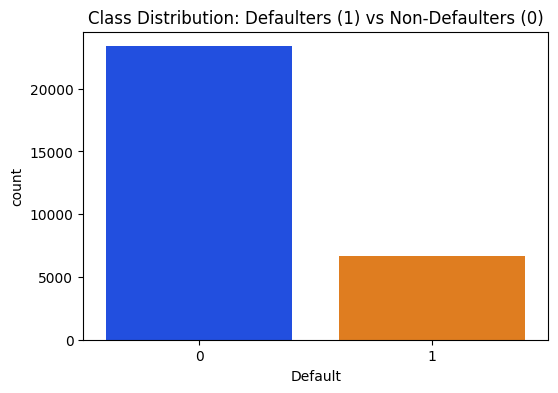

Non-Default: 77.88%, Default: 22.12%


In [50]:
# Check Target Variable Balance
plt.figure(figsize=(6, 4))
sns.countplot(x='Default', data=df_labelled, palette='bright')
plt.title('Class Distribution: Defaulters (1) vs Non-Defaulters (0)')
plt.show()

# Ratio
default_ratio = df['Default'].value_counts(normalize=True)
print(f"Non-Default: {default_ratio[0]:.2%}, Default: {default_ratio[1]:.2%}")

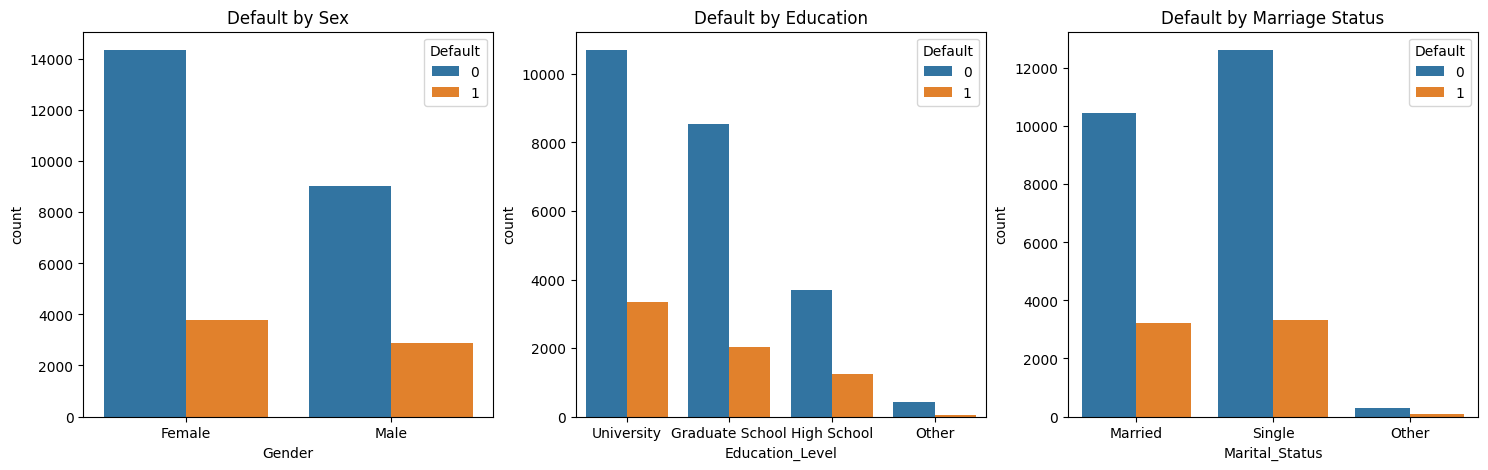

In [51]:
# Analysing the demographic of the dataset (Sex, Education, Marriage)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(x='Gender', hue='Default', data=df_labelled, ax=ax[0])
ax[0].set_title('Default by Sex')

sns.countplot(x='Education_Level', hue='Default', data=df_labelled, ax=ax[1])
ax[1].set_title('Default by Education')

sns.countplot(x='Marital_Status', hue='Default', data=df_labelled, ax=ax[2])
ax[2].set_title('Default by Marriage Status')
plt.show()

##### From the above plots, we can get that male cusotmers show a slightly higher default rate than females ones and lowest default rate among the education groups is seen with graduate school customers.

##### Married customers have a slightly higher possibility of default rate than single customers.

In [52]:
# Column groups for visualisation
bill_amt_cols = ['Bill_Amount_Sept', 'Bill_Amount_Aug', 'Bill_Amount_July', 'Bill_Amount_June', 'Bill_Amount_May', 'Bill_Amount_April']

# Check for negatives in Bill Amounts 
neg_bill_amt = df[bill_amt_cols][df[bill_amt_cols] < 0].count()
print('\nNegative counts in BILL_AMT columns:\n', neg_bill_amt)


Negative counts in BILL_AMT columns:
 Bill_Amount_Sept     590
Bill_Amount_Aug      669
Bill_Amount_July     655
Bill_Amount_June     675
Bill_Amount_May      655
Bill_Amount_April    688
dtype: int64



Default Rate by Has_Neg_Bill:
 Has_Neg_Bill
False    0.225080
True     0.164767
Name: Default, dtype: float64


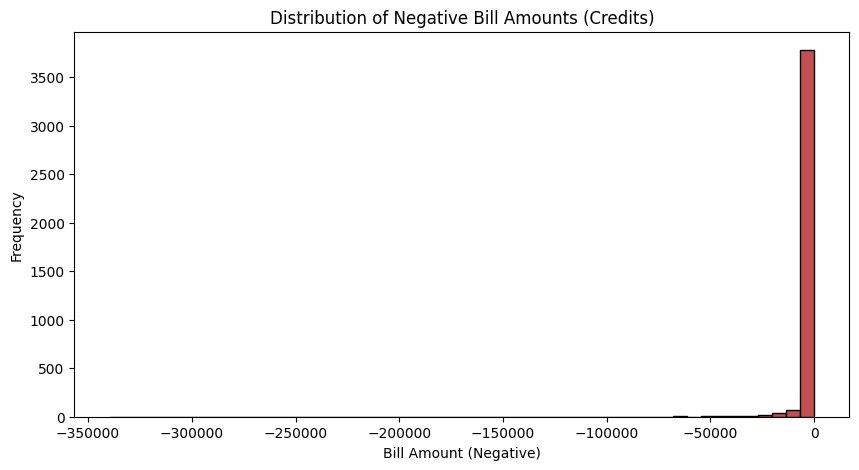

In [53]:
# Distribution of Negative Bill Amounts on cleaned dataset
all_bills = df[bill_amt_cols].values.flatten()
neg_bills = all_bills[all_bills < 0]

# Visualisation graph for negative amounts
plt.figure(figsize=(10, 5))
plt.hist(neg_bills, bins=50, color='#c44e52', edgecolor='black')
plt.title('Distribution of Negative Bill Amounts (Credits)')
plt.xlabel('Bill Amount (Negative)')
plt.ylabel('Frequency')

# Check Default Rate for Negative vs Positive Bill Amounts 
df['Has_Neg_Bill'] = (df[bill_amt_cols] < 0).any(axis=1)

# Calculate default rate
default_rates = df.groupby('Has_Neg_Bill')['Default'].mean()
print('\nDefault Rate by Has_Neg_Bill:\n', default_rates)


##### From the above plot, we can observe that the people who overpay or have less credits have lesser deafult rate than the average customer.

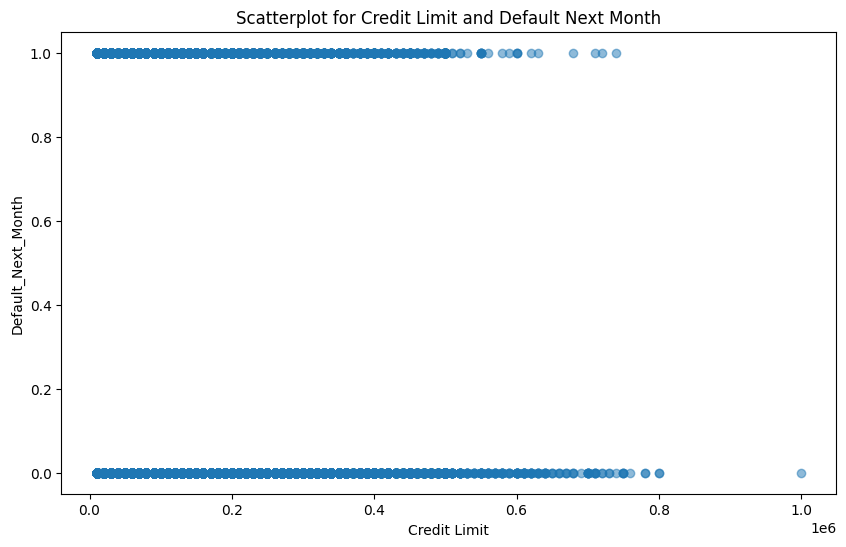

In [54]:
# Plot the credit limit vs default next month for cleaned data to check for outliers
plt.figure(figsize=(10, 6))
plt.scatter(df['Credit_Limit'], df['Default'], alpha=0.5) 
plt.title('Scatterplot for Credit Limit and Default Next Month')
plt.xlabel('Credit Limit')
plt.ylabel('Default_Next_Month')
plt.show() 

#### As we can see that the above dataset has outliers so let's filter them down.

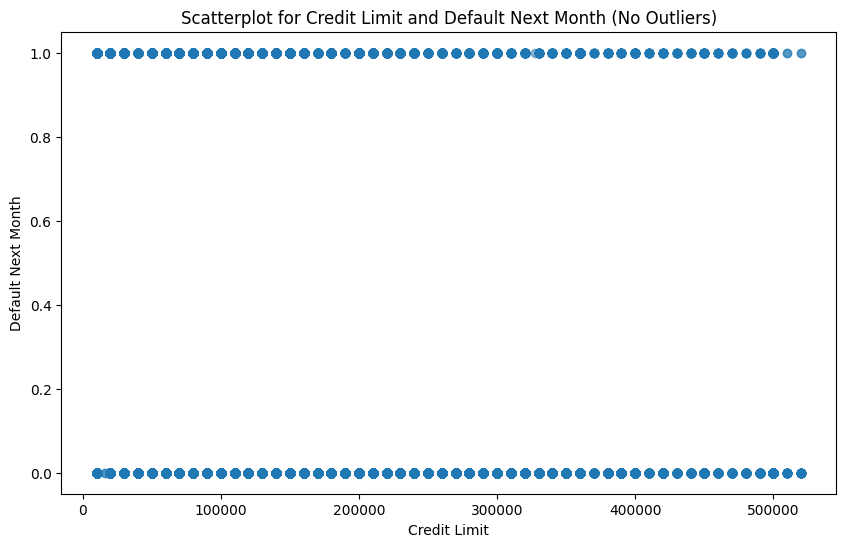

In [55]:
# Calculate the quantiles for 'Credit Limit'
Q1 = df['Credit_Limit'].quantile(0.25)
Q3 = df['Credit_Limit'].quantile(0.75)
IQR = Q3 - Q1

# Define the upper bound to filter outliers
upper_bound = Q3 + 1.5 * IQR

# Filter the DataFrame to exclude outliers
df_no_outliers = df[df['Credit_Limit'] <= upper_bound]

# Scatterplot for Credit Limit  and Default Next Month without outliers
plt.figure(figsize=(10, 6))
plt.scatter(df_no_outliers['Credit_Limit'], df_no_outliers['Default'], alpha=0.5)
plt.title('Scatterplot for Credit Limit and Default Next Month (No Outliers)')
plt.xlabel('Credit Limit')
plt.ylabel('Default Next Month')
plt.show()

In [56]:
# Compare the values removed as part of outlier removal 
print(f"No of rows in the original data size: {df.shape[0]}")
print(f"No of rows in the cleaned data size without outliers: {df_no_outliers.shape[0]}")

No of rows in the original data size: 30000
No of rows in the cleaned data size without outliers: 29833


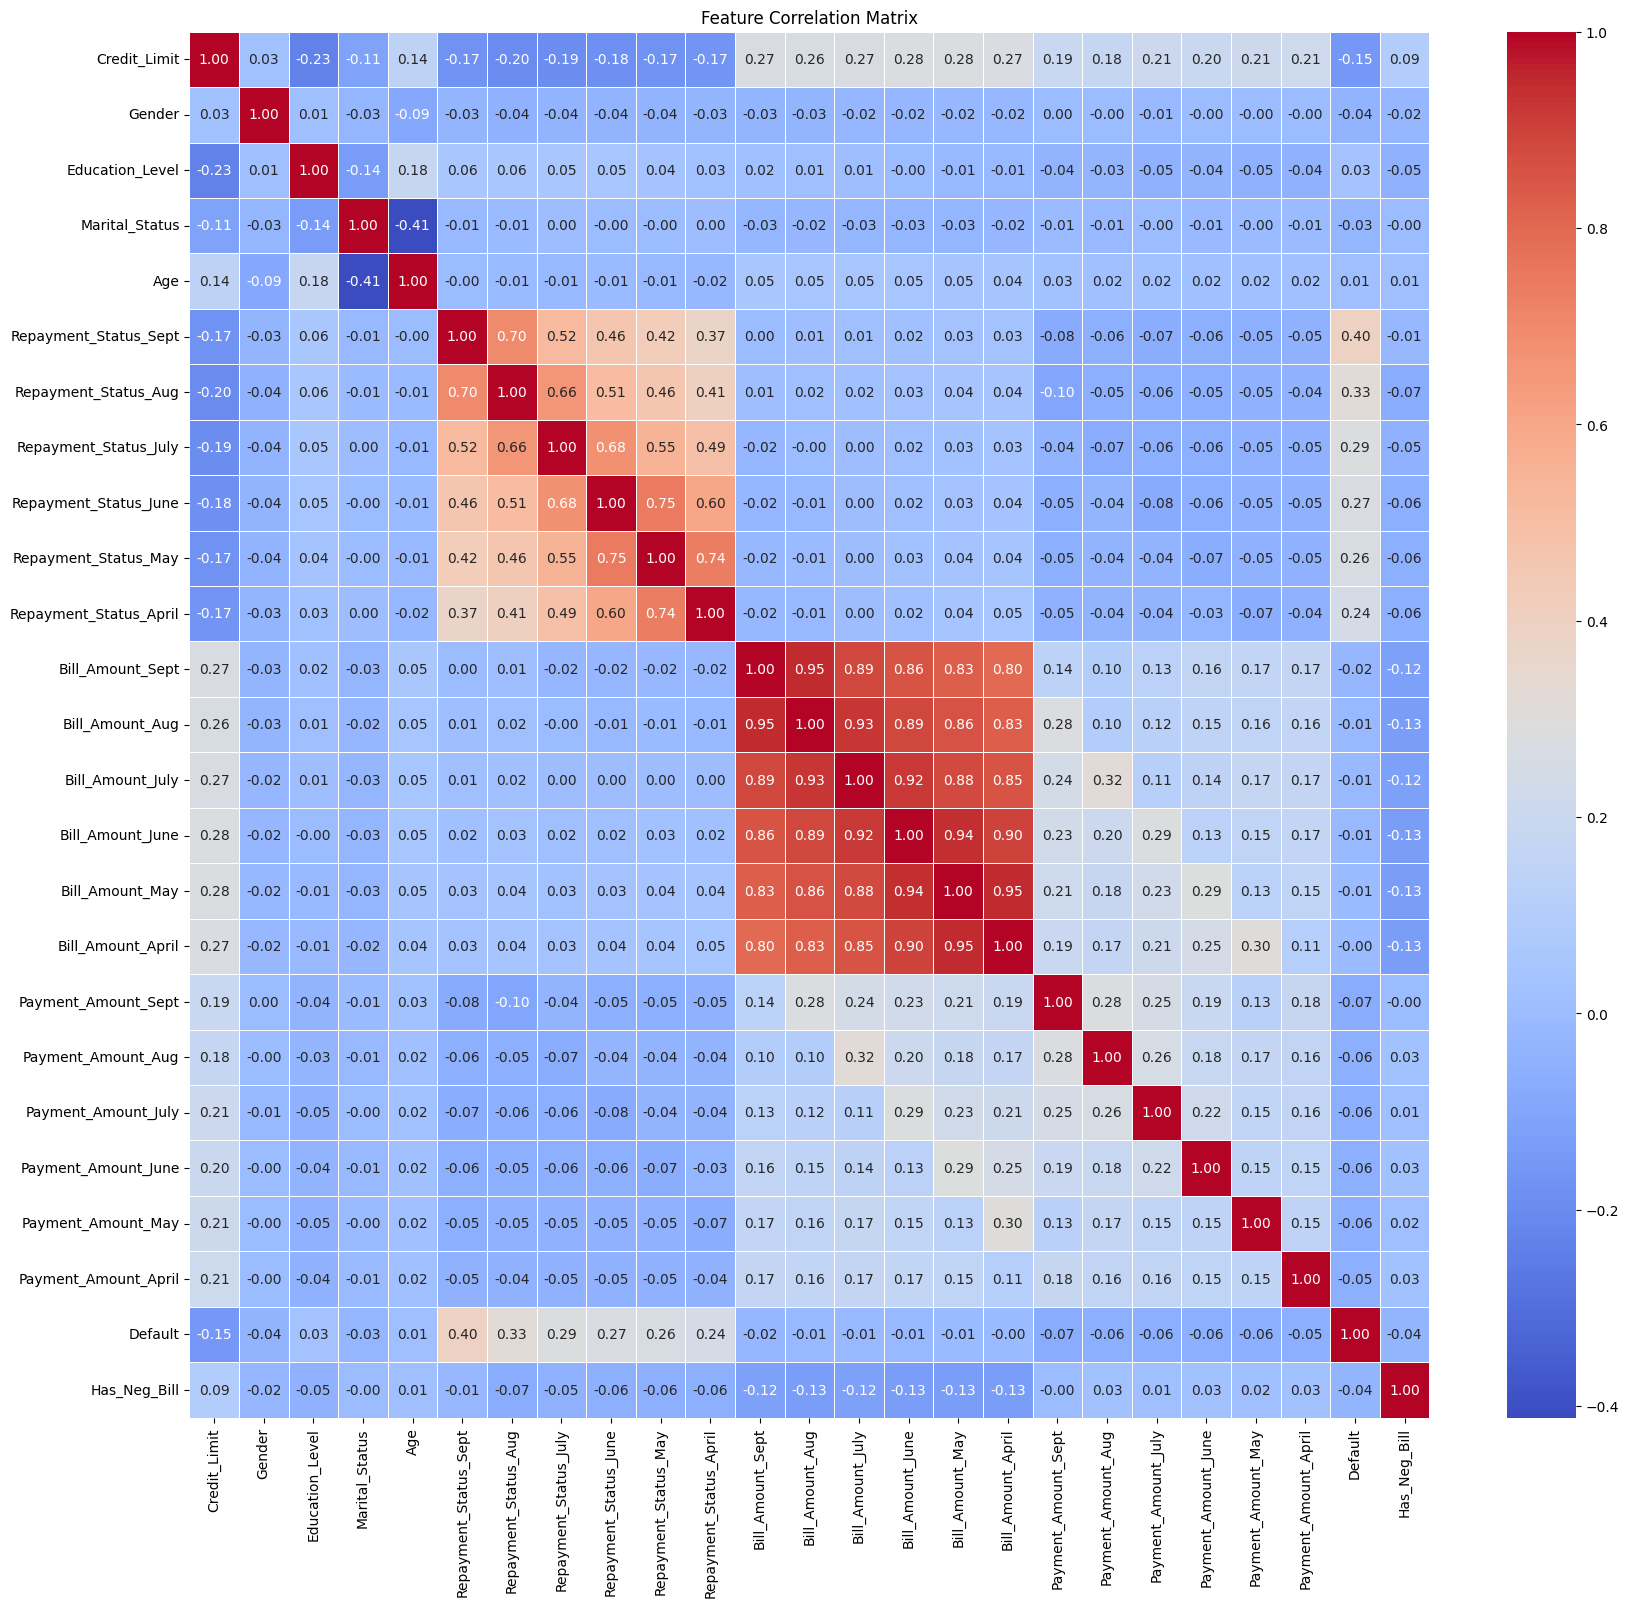

In [57]:
# Dropping ID column becuase it does not represent any useful information for training
df_no_outliers = df_no_outliers.drop('ID', axis=1)

# Checking for multicollinearity with Correlation Matrix
# Logistic Regression does not work if features are highly correlated.
corr_matrix = df_no_outliers.corr()
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

In [58]:
# Select Feature Variables
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            high_corr_pairs.append((colname_i, colname_j, corr_matrix.iloc[i, j]))

print('Highly Correlated Pairs (> 0.9):')
for pair in high_corr_pairs:
    print(pair)

Highly Correlated Pairs (> 0.9):
('Bill_Amount_Aug', 'Bill_Amount_Sept', np.float64(0.9496958682917349))
('Bill_Amount_July', 'Bill_Amount_Aug', np.float64(0.9257344721318094))
('Bill_Amount_June', 'Bill_Amount_July', np.float64(0.9222839190960959))
('Bill_Amount_May', 'Bill_Amount_June', np.float64(0.9396374265235734))
('Bill_Amount_April', 'Bill_Amount_June', np.float64(0.9002787467292944))
('Bill_Amount_April', 'Bill_Amount_May', np.float64(0.9454637287733709))


##### We can deduce that credit limit has  negative corelation with the target variable default next month which suggests that clients with higher limits are less likely to default.

##### Only 22% of users defualt. We need to fix this becuase if not the model might just predict Non-default for everyone and achieve ~70% accuracy which will be useless

##### The heatmaps shows multicollinearity among Bill amount features. This confirms we must engineer these features. 

In [59]:
# Fixing multicollinearity
df_eng = df_no_outliers.copy().reset_index(drop=True)

bill_cols = ['Bill_Amount_Sept', 'Bill_Amount_Aug', 'Bill_Amount_July', 
             'Bill_Amount_June', 'Bill_Amount_May', 'Bill_Amount_April']

# Calculate the row-wise mean 
df_eng['Bill_Amount_Avg'] = df_eng[bill_cols].mean(axis=1)

# Drop the Original Highly Correlated Columns
# We remove the 6 individual bill columns to eliminate multicollinearity
df_eng = df_eng.drop(columns=bill_cols)

# Handling Pay amounts
# Creating an "Average Pay Amount" to show spending power
pay_amt_cols = ['Payment_Amount_Sept', 'Payment_Amount_Aug', 'Payment_Amount_July', 'Payment_Amount_June', 'Payment_Amount_May', 'Payment_Amount_April']
df_eng['Pay_Amount_Avg'] = df_eng[pay_amt_cols].mean(axis=1)
df_eng = df_eng.drop(columns=pay_amt_cols)

# Creating a pay to bill ration column
df_eng['Pay_To_Bill_Ratio'] = 0.0  

for i in range(len(df_eng)):
    bill = df_eng.loc[i, 'Bill_Amount_Avg']
    pay = df_eng.loc[i, 'Pay_Amount_Avg']
    
    if bill > 0:
        df_eng.loc[i, 'Pay_To_Bill_Ratio'] = pay / bill
    else:
        df_eng.loc[i, 'Pay_To_Bill_Ratio'] = 0

# One Hot Encoding for Categorical vaiables
cat_cols = ["Gender", 'Education_Level', 'Marital_Status']
df_eng = pd.get_dummies(df_eng, columns=cat_cols, drop_first=True, dtype=int)

print('Features Engineering Complete')

Features Engineering Complete


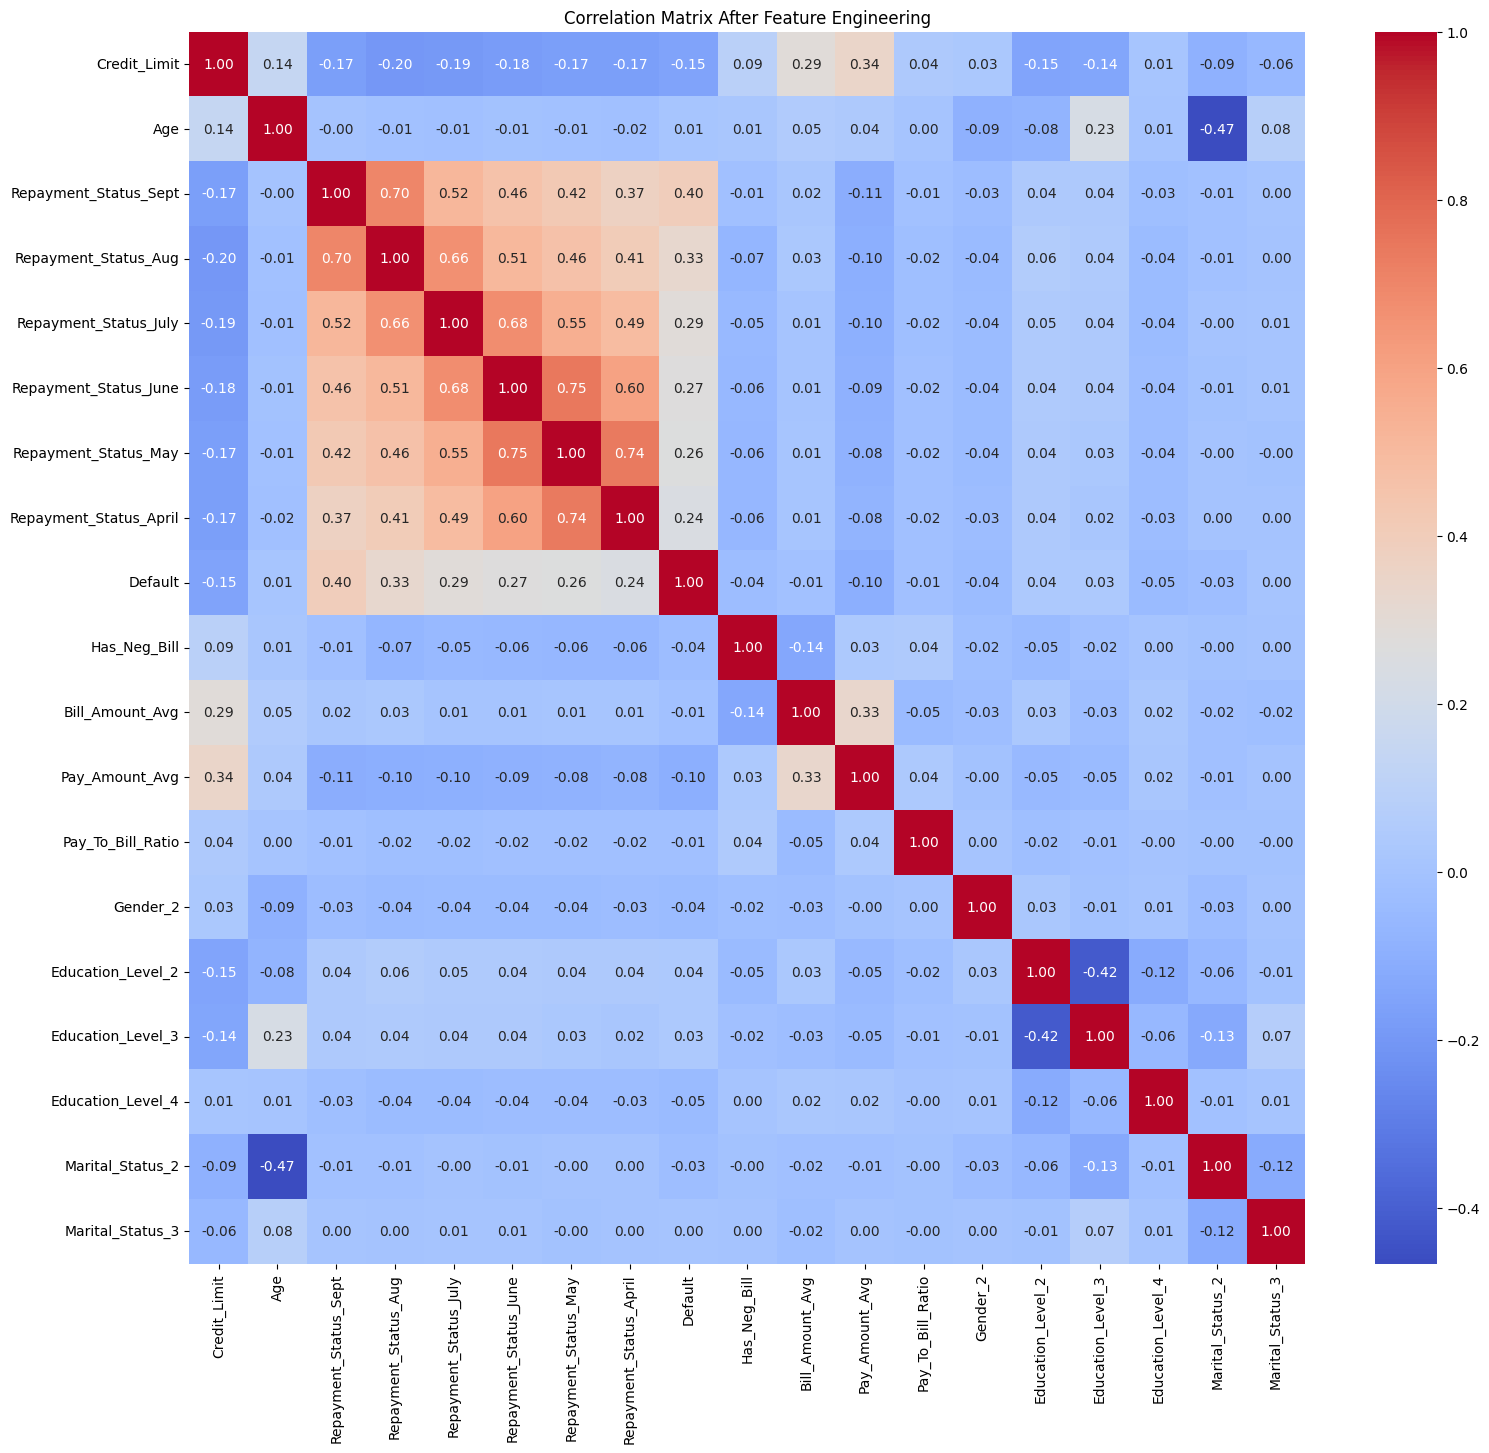

SUCCESS: No variable pairs have a correlation > 0.9.


In [60]:
# Validate Collinearity Removal
corr_matrix_reduced = df_eng.corr(numeric_only=True)

# Plot Heatmap
plt.figure(figsize=(18, 16))
sns.heatmap(corr_matrix_reduced, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix After Feature Engineering')
plt.show()

# Automated Check for High Correlation
high_corr_pairs = []
cols = corr_matrix_reduced.columns
for i in range(len(cols)):
    for j in range(i):
        if abs(corr_matrix_reduced.iloc[i, j]) > 0.9:
            high_corr_pairs.append((cols[i], cols[j], corr_matrix_reduced.iloc[i, j]))

if not high_corr_pairs:
    print('SUCCESS: No variable pairs have a correlation > 0.9.')
else:
    print('WARNING: High correlation still exists:', high_corr_pairs)

## Model Training

In [61]:
# Feature Selection
drop_cols = ['Default', 'Has_Neg_Bill']

X = df_eng.drop(drop_cols, axis=1)
y = df_eng['Default']

# Splitting the dataset
# stratify=y ensure that we keep the default 22% cases in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Logistic Regression

In [62]:
# Preprocessing for Logistic Regression
# Applying Scaling becuase logistic regression requires input features to be on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Applying SMOTE oversampling to take care of 22/78 imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print('New Training Shape: ', X_train_resampled.shape)

print('\n Before SMOTE:', y_train.value_counts())
print('After SMOTE:', pd.Series(y_train_resampled).value_counts())

New Training Shape:  (37144, 17)

 Before SMOTE: Default
0    18572
1     5294
Name: count, dtype: int64
After SMOTE: Default
0    18572
1    18572
Name: count, dtype: int64


In [63]:
# Training Logistic Regression model
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train_resampled, y_train_resampled)

# Predicting
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      4644
           1       0.48      0.54      0.51      1323

    accuracy                           0.77      5967
   macro avg       0.67      0.69      0.68      5967
weighted avg       0.78      0.77      0.77      5967

ROC-AUC Score: 0.7489768900190952


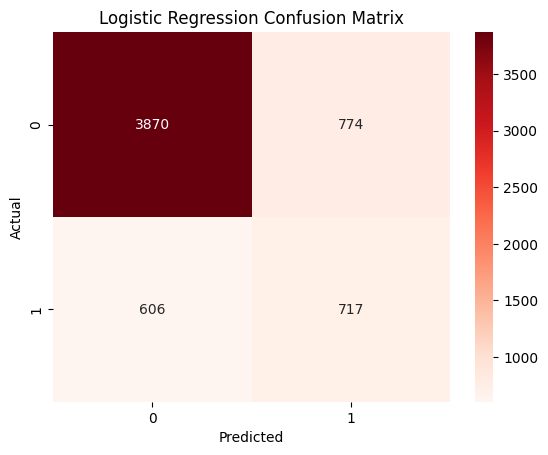

In [64]:
# Evaluation
print('Logistic Regression Classification Report')
print(classification_report(y_test, y_pred_lr))
print('ROC-AUC Score:', roc_auc_score(y_test, y_prob_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds')
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Random Forest

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      4644
           1       0.53      0.50      0.52      1323

    accuracy                           0.79      5967
   macro avg       0.70      0.69      0.69      5967
weighted avg       0.79      0.79      0.79      5967

ROC-AUC Score: 0.7658409521335571


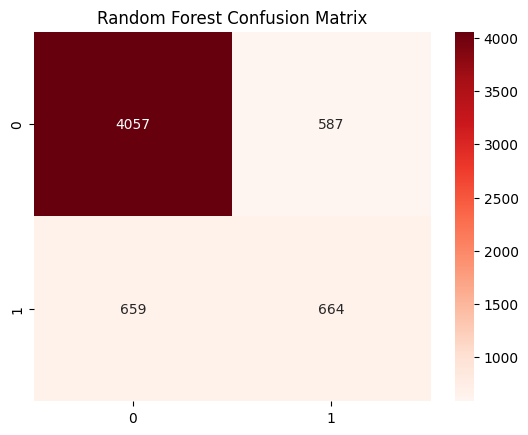

In [65]:
# Training Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predicting with rf
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print('Random Forest Classification Report')
print(classification_report(y_test, y_pred_rf))
print('ROC-AUC Score:', roc_auc_score(y_test, y_prob_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds')
plt.title('Random Forest Confusion Matrix')
plt.show()

### XGBoost

XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4644
           1       0.65      0.36      0.46      1323

    accuracy                           0.81      5967
   macro avg       0.74      0.65      0.67      5967
weighted avg       0.79      0.81      0.79      5967

ROC-AUC Score: 0.7703987231795772


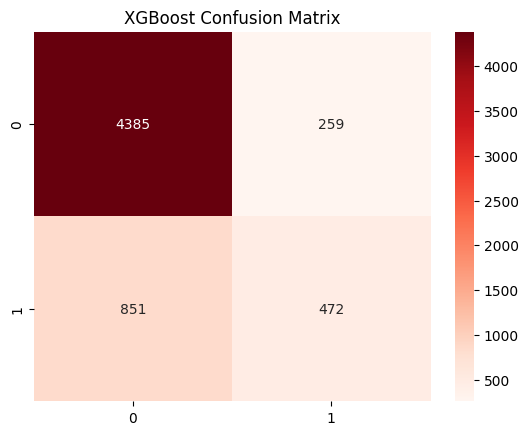

In [66]:
# Training XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss', 
)

xgb_model.fit(X_train, y_train)

# Predicting with xbg
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]


# Evaluation
print('XGBoost Classification Report')
print(classification_report(y_test, y_pred_xgb))
print('ROC-AUC Score:', roc_auc_score(y_test, y_prob_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds')
plt.title('XGBoost Confusion Matrix')
plt.show()

In [67]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

print('Comparison of Model Performance')
print(results)

Comparison of Model Performance
                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.768728  0.748977
1        Random Forest  0.791185  0.765841
2              XGBoost  0.813977  0.770399
